In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

Data Preprocessing

In [16]:
#  Load dataset
df = pd.read_csv('enhanced_house_price_dataset.csv')

# Quick look at data
print("Shape:", df.shape)
print(df.head(10))

#  Checking missing values
print("Missing values:\n", df.isnull().sum())

#  Drop rows with missing values (simple clean)
df = df.dropna()

Shape: (2000, 16)
   Area  Bedrooms  Bathrooms  Stories  Parking  Age       City  \
0  1260         4          3        2        1   24       Pune   
1  5790         2          1        1        1    7    Kolkata   
2  5626         5          2        3        0   15    Chennai   
3  5591         1          1        1        1   47      Delhi   
4  4172         5          1        1        1   44      Delhi   
5  3492         5          1        3        1   14     Mumbai   
6   866         2          2        3        1    0  Hyderabad   
7  5734         1          1        3        2   21     Mumbai   
8  4826         2          2        2        1    2    Chennai   
9  5978         3          3        3        1   37    Chennai   

       Furnishing Main Road Guest Room Basement Water Supply Air Conditioning  \
0  Semi-Furnished       Yes        Yes      Yes         Both               No   
1     Unfurnished       Yes        Yes      Yes         Both              Yes   
2  Semi-Furn

Check Column Types

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Area              2000 non-null   int64
 1   Bedrooms          2000 non-null   int64
 2   Bathrooms         2000 non-null   int64
 3   Stories           2000 non-null   int64
 4   Parking           2000 non-null   int64
 5   Age               2000 non-null   int64
 6   City              2000 non-null   str  
 7   Furnishing        2000 non-null   str  
 8   Main Road         2000 non-null   str  
 9   Guest Room        2000 non-null   str  
 10  Basement          2000 non-null   str  
 11  Water Supply      2000 non-null   str  
 12  Air Conditioning  2000 non-null   str  
 13  Preferred Tenant  2000 non-null   str  
 14  Locality Rating   2000 non-null   int64
 15  Price             2000 non-null   int64
dtypes: int64(8), str(8)
memory usage: 333.6 KB


Check Null Values 

In [18]:
df.isnull().sum()

Area                0
Bedrooms            0
Bathrooms           0
Stories             0
Parking             0
Age                 0
City                0
Furnishing          0
Main Road           0
Guest Room          0
Basement            0
Water Supply        0
Air Conditioning    0
Preferred Tenant    0
Locality Rating     0
Price               0
dtype: int64

 Split features and target

In [19]:

X = df.drop("Price", axis=1)
y = df["Price"]


In [43]:
print(X.head())
print(X.dtypes)

   Area  Bedrooms  Bathrooms  Stories  Parking  Age     City      Furnishing  \
0  1260         4          3        2        1   24     Pune  Semi-Furnished   
1  5790         2          1        1        1    7  Kolkata     Unfurnished   
2  5626         5          2        3        0   15  Chennai  Semi-Furnished   
3  5591         1          1        1        1   47    Delhi       Furnished   
4  4172         5          1        1        1   44    Delhi     Unfurnished   

  Main Road Guest Room Basement Water Supply Air Conditioning  \
0       Yes        Yes      Yes         Both               No   
1       Yes        Yes      Yes         Both              Yes   
2        No        Yes      Yes  Corporation              Yes   
3       Yes         No      Yes     Borewell               No   
4        No         No       No     Borewell              Yes   

  Preferred Tenant  Locality Rating  
0          Company                4  
1         Bachelor                5  
2          Com

Convert Categorical Column  and Split Training Testing data

In [21]:

X = df.drop("Price", axis=1)
y = df["Price"]

categorical_cols = X.select_dtypes(include=['object','string']).columns
numeric_cols = X.select_dtypes(include=['int64','float64']).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=300, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)

joblib.dump(model, "model.pkl")



['model.pkl']

In [22]:
print('Training Data', X_train.shape[0])
print('Testing Data', X_test.shape[0])

Training Data 1600
Testing Data 400


In [23]:
model = joblib.load("model.pkl")

print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [24]:
# ================================================
# 3. MODELS
# ================================================
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6
    )
}

Train and Evalute all Models

In [41]:
results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X, y)
    preds = pipe.predict(X)

    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)

    
    print("\n===============================")
    print(f"MODEL: {name}")
    print("===============================")
    print(f"R² Score : {r2:.4f}")
    print(f"MAE      : {mae:.4f}")
    print(f"MSE      : {mse:.4f}")
    print(f"RMSE     : {rmse:.4f}")
   
    results[name] = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}

results_df = pd.DataFrame(results).T
print(results_df)


MODEL: Linear Regression
R² Score : 0.7513
MAE      : 118920.3423
MSE      : 22393757303.4288
RMSE     : 149645.4386

MODEL: Random Forest
R² Score : 0.9515
MAE      : 52519.5801
MSE      : 4370807134.1635
RMSE     : 66112.0801

MODEL: XGBoost
R² Score : 0.9704
MAE      : 38575.0312
MSE      : 2662550528.0000
RMSE     : 51599.9082
                            MSE           RMSE            MAE        R2
Linear Regression  2.239376e+10  149645.438632  118920.342339  0.751345
Random Forest      4.370807e+09   66112.080093   52519.580117  0.951468
XGBoost            2.662551e+09   51599.908217   38575.031250  0.970436


VISUALIZATIONS


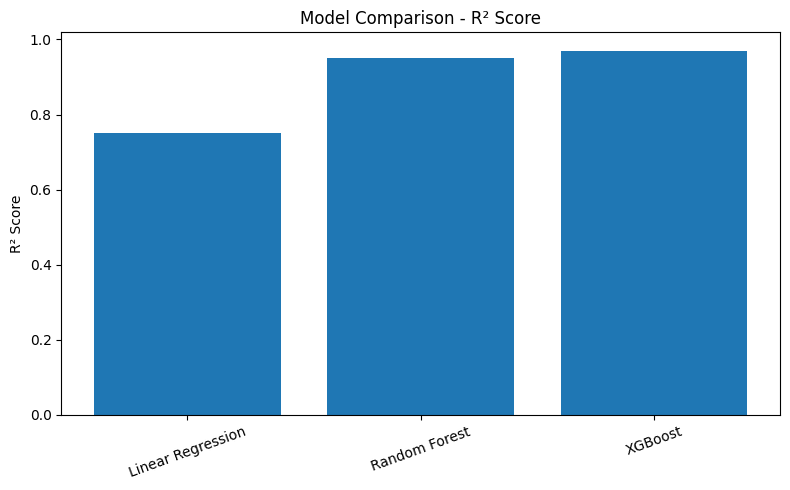

In [45]:
#R² Score Comparison
plt.figure(figsize=(8,5))
plt.bar(results.keys(), [results[m]["R2"] for m in results])
plt.title("Model Comparison - R² Score")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

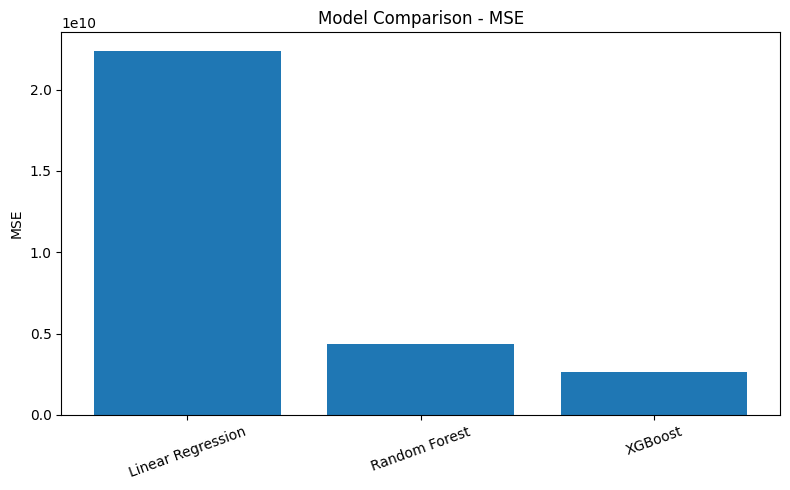

In [46]:
#MSE Comparison
plt.figure(figsize=(8,5))
plt.bar(results.keys(), [results[m]["MSE"] for m in results])
plt.title("Model Comparison - MSE")
plt.ylabel("MSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

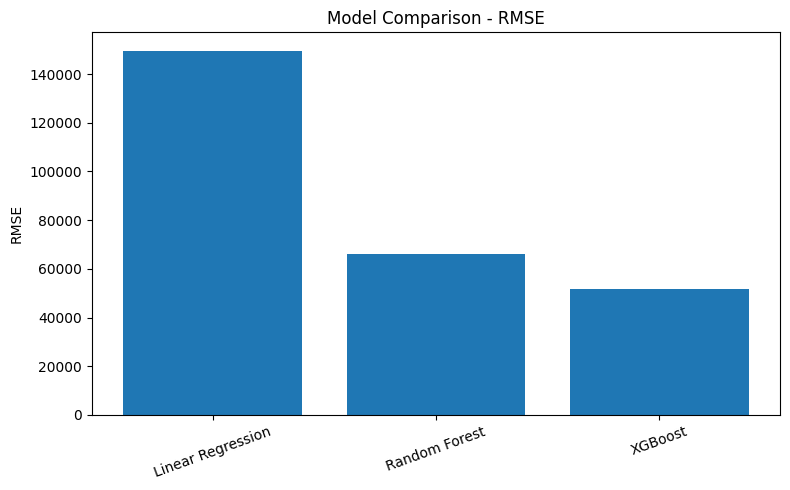

In [47]:
#RMSE Comparison
plt.figure(figsize=(8,5))
plt.bar(results.keys(), [results[m]["RMSE"] for m in results])
plt.title("Model Comparison - RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

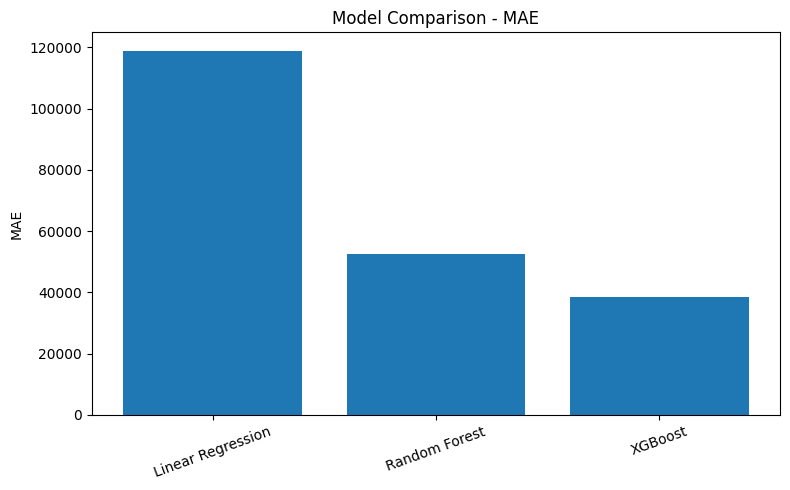

In [48]:
#MAE Comparison
plt.figure(figsize=(8,5))
plt.bar(results.keys(), [results[m]["MAE"] for m in results])
plt.title("Model Comparison - MAE")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Save Best Model with Joblib

In [42]:
best_model_name = results_df["R2"].idxmax()
print("Best Model:", best_model_name)

best_model = models[best_model_name]

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

final_pipeline.fit(X, y)

joblib.dump(final_pipeline, "model.joblib")

print("Model saved as model.joblib")

Best Model: XGBoost
Model saved as model.joblib
